#### What is a Rug Plot (rugplot)?
A rug plot is a very simple plot that displays the distribution of a single numerical variable by drawing small vertical lines (or "ticks") along an axis for every single data point.

It's called a "rug plot" because it looks like the tassels on the edge of a rug. It doesn't use bars or curves; it just shows the exact location of every observation.

Its primary purpose is not to be used alone, but to be added to another, more complex plot (like a histogram or KDE plot) to provide extra detail.

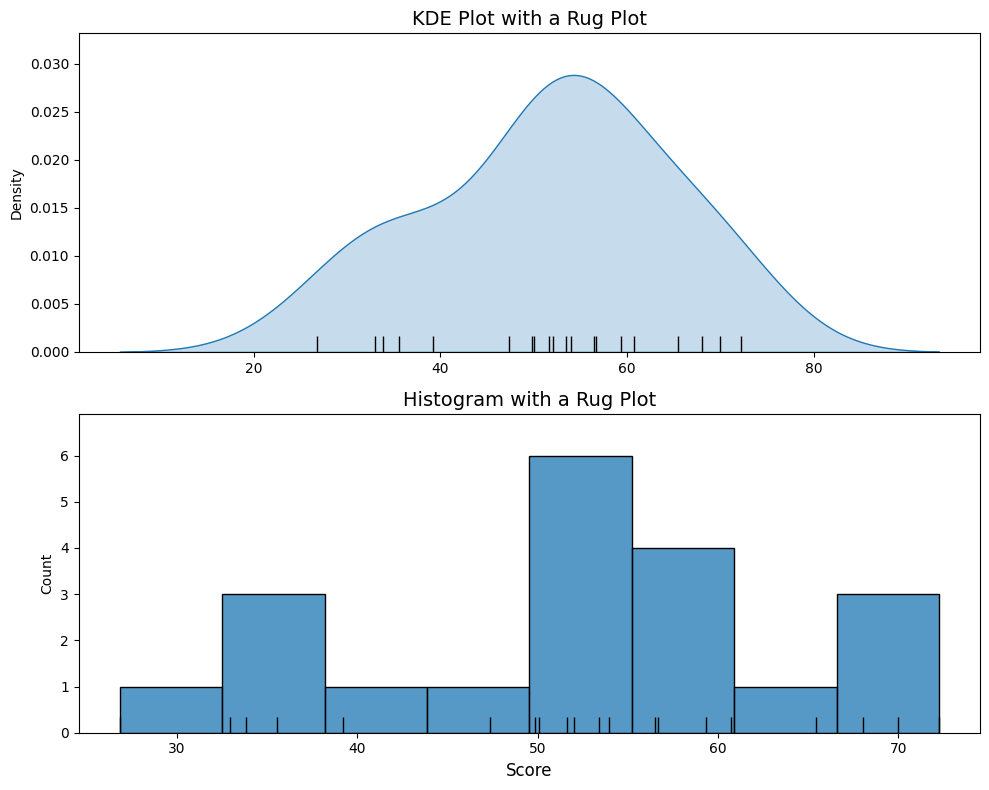

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Sample Data
# Create a small dataset of 20 points to make the rug plot easy to see.
np.random.seed(10) # for reproducibility
data = np.random.normal(loc=50, scale=15, size=20)
df = pd.DataFrame({'score': data})

# 2. Sample Code for the Plot

# Create a figure with two subplots to show the rug plot in context
fig, axes = plt.subplots(2, 1, figsize=(10, 8))


# --- Plot 1: A KDE Plot with a Rug Plot ---
sns.kdeplot(data=df, x='score', fill=True, ax=axes[0])
# Add the rug plot to the same axes
# The rug plot will automatically align with the x-axis of the parent plot.
sns.rugplot(data=df, x='score', ax=axes[0], height=0.05, color='black')
axes[0].set_title('KDE Plot with a Rug Plot', fontsize=14)
axes[0].set_xlabel('') # Remove x-label to avoid overlap


# --- Plot 2: A Histogram with a Rug Plot ---
sns.histplot(data=df, x='score', bins=8, ax=axes[1])
# Add the rug plot to the second axes
sns.rugplot(data=df, x='score', ax=axes[1], height=0.05, color='black')
axes[1].set_title('Histogram with a Rug Plot', fontsize=14)
axes[1].set_xlabel('Score', fontsize=12)


plt.tight_layout()
plt.show()

#### What Type of Information It Provides
A rug plot adds a layer of detail that can be lost in aggregated plots like histograms or KDEs.

- Exact Location of Individual Data Points: This is its primary function. While a histogram bar shows you that there are 5 points between 40 and 50, the rug plot shows you exactly where those 5 points are located within that bin.

- Data Density and Sparsity: It provides a raw, un-summarized view of where the data is dense (many ticks close together) and where it is sparse (ticks are far apart). This can help you validate what you see in the KDE curve.

- Highlights Gaps and Outliers: It makes it very obvious if there are large gaps in your data where no observations exist. It also clearly shows individual ticks that are far away from the main group, highlighting potential outliers.

- Reveals Subtleties Lost in Binning: A histogram's shape can change depending on the bin width. The rug plot is "ground truth"—it's not affected by any parameters. It can help you see if a single peak in a histogram is actually composed of two very close-by mini-clusters of data points.

#### Scenarios for Using a Rug Plot
As mentioned, a rug plot is almost always used in combination with another plot.

-  During Exploratory Data Analysis (EDA)
- To Enhance Histograms and KDE Plots: This is the most common use case. Adding a rug plot provides a direct link between the summarized distribution (the bars or curve) and the underlying raw data points. It helps you build confidence in the primary plot.
Example: You see a tall bar in a histogram. The rug plot below it will show a dense cluster of ticks, confirming the high frequency in that bin.
- To Supplement Scatter Plots: You can add a rug plot to the x and y axes of a scatter plot to show the marginal distributions of each variable. This is exactly what seaborn.jointplot does by default.
Example: A scatter plot of height vs. weight can have a rug plot on the x-axis showing the distribution of heights and another on the y-axis showing the distribution of weights.
-  Data Validation and Debugging
Checking the Effect of Binning: If you are creating a histogram and are unsure about the number of bins, adding a rug plot can help you see how different bin choices group the underlying data points.
- Verifying Data Transformations: After applying a transformation like a log transform, you can use a rug plot to see how the spacing between the data points has changed.
##### When Not to Use It
- On Its Own: A standalone rug plot is rarely useful, as it's hard to interpret density from just the ticks, especially with a lot of data.
- With Very Large Datasets: If you have millions of data points, the rug plot will just become a solid, thick line, losing all its detail. - In this case, it's not helpful. It's best for small to medium-sized datasets where you can still distinguish individual ticks.